In [1]:
# The presented code and results belong to the following publication:
# N. Sikder and A. Nahid, “KU-HAR: An open dataset for heterogeneous human activity recognition,” Pattern Recognition Letters, vol. 146, pp. 46–54, Jun. 2021, doi: 10.1016/j.patrec.2021.02.024.

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [3]:
#Reading data:

df = pd.read_csv("../input/kuhar/3.Time_domain_subsamples/KU-HAR_time_domain_subsamples_20750x300.csv",header=None)
dff = df.values
signals = dff[:, 0: 1800] #These are the time-domian subsamples (signals) 
signals = np.array(signals, dtype=np.float32)
labels = dff[:, 1800] #These are their associated class labels (signals)

print(signals.shape)
print(labels.shape)

(20750, 1800)
(20750,)


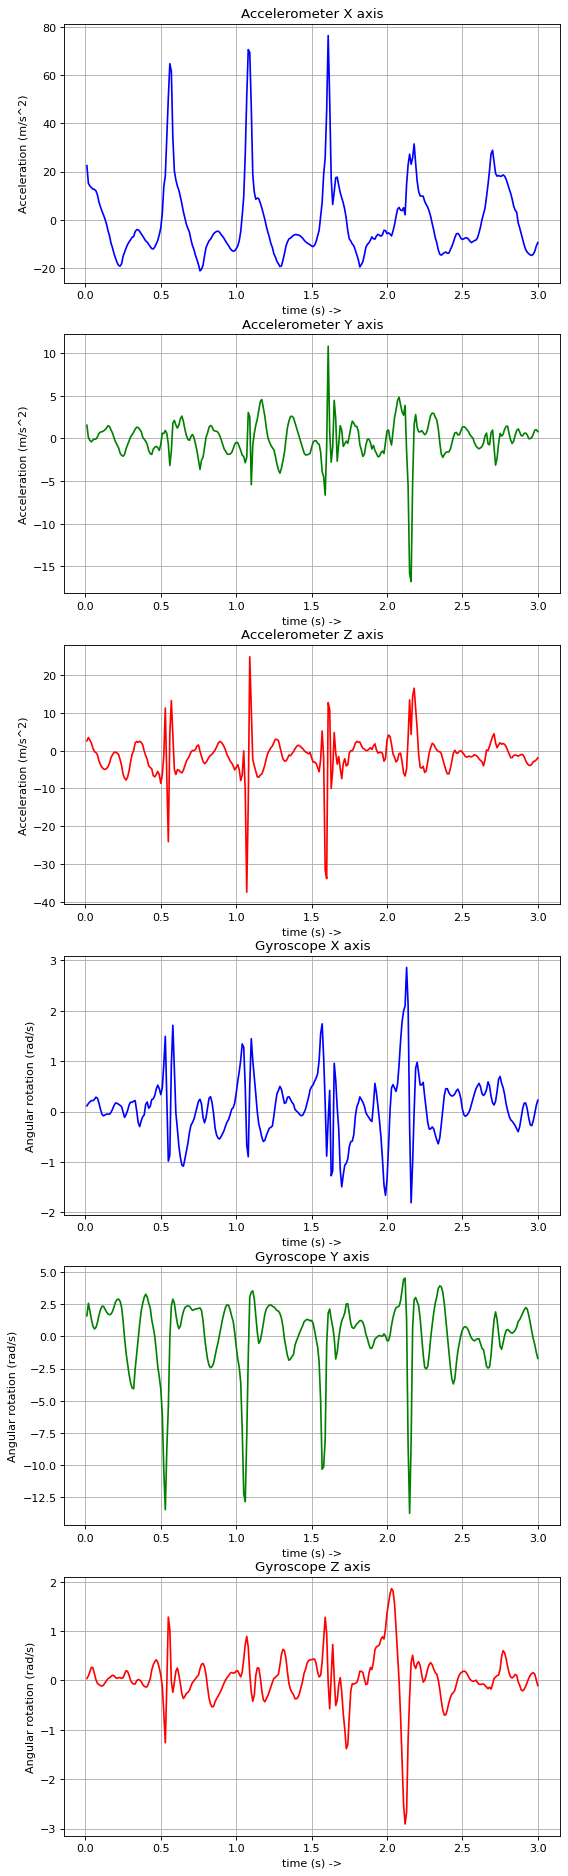

In [4]:
# Visualization of the 20001th sample (the correspondig activity is "Jump"):

Accelerometer_X_axis_data = signals[20000, 0: 300]
Accelerometer_Y_axis_data = signals[20000, 300: 600]
Accelerometer_Z_axis_data = signals[20000, 600: 900]
Gyroscope_X_axis_data = signals[20000, 900: 1200]
Gyroscope_Y_axis_data = signals[20000, 1200: 1500]
Gyroscope_Z_axis_data = signals[20000, 1500: 1800]
time = np.linspace(.01, 3, 300)

figure(figsize=(8, 30), dpi=80)

ax1 = plt.subplot(611)
ax1.plot(time, Accelerometer_X_axis_data, 'b')
ax1.title.set_text('Accelerometer X axis')
ax1.set_xlabel('time (s) ->')
ax1.set_ylabel('Acceleration (m/s^2)')
ax1.grid(True)

ax2 = plt.subplot(612)
ax2.plot(time, Accelerometer_Y_axis_data, 'g')
ax2.title.set_text('Accelerometer Y axis')
ax2.set_xlabel('time (s) ->')
ax2.set_ylabel('Acceleration (m/s^2)')
ax2.grid(True)

ax3 = plt.subplot(613)
ax3.plot(time, Accelerometer_Z_axis_data, 'r')
ax3.title.set_text('Accelerometer Z axis')
ax3.set_xlabel('time (s) ->')
ax3.set_ylabel('Acceleration (m/s^2)')
ax3.grid(True)

ax4 = plt.subplot(614)
ax4.plot(time, Gyroscope_X_axis_data, 'b')
ax4.title.set_text('Gyroscope X axis')
ax4.set_xlabel('time (s) ->')
ax4.set_ylabel('Angular rotation (rad/s)')
ax4.grid(True)

ax5 = plt.subplot(615)
ax5.plot(time, Gyroscope_Y_axis_data, 'g')
ax5.title.set_text('Gyroscope Y axis')
ax5.set_xlabel('time (s) ->')
ax5.set_ylabel('Angular rotation (rad/s)')
ax5.grid(True)

ax6 = plt.subplot(616)
ax6.plot(time, Gyroscope_Z_axis_data, 'r')
ax6.title.set_text('Gyroscope Z axis')
ax6.set_xlabel('time (s) ->')
ax6.set_ylabel('Angular rotation (rad/s)')
ax6.grid(True)

plt.show()

In [5]:
# DFT of the time-domain signals, separately for each channel

fft = np.zeros(signals.shape, dtype=np.float32)
for i in range(0,len(signals)):
    for j in range(0, 6):
        tmp = np.fft.fft(signals[i, j*300:(j+1)*300])
        fft[i, j*300:(j+1)*300] = abs(tmp)
        
print(fft.shape)

(20750, 1800)


In [6]:
# Creating Training and Test subsets with randomly chosen samples:

X_train, X_test, y_train, y_test=train_test_split(fft,labels, test_size=0.3, random_state=9, stratify=labels)
print(X_train.shape)
print(X_test.shape)

(14525, 1800)
(6225, 1800)


In [7]:
# Classifying HAR samples:

lr_r = RandomForestClassifier(n_estimators=300, max_features='sqrt')
lr_r.fit(X_train,  y_train)
accuracy_r = lr_r.score(X_test, y_test)

In [8]:
# Showing results:

print('Classification Accuracy: ',accuracy_r)
y_pred=lr_r.predict(X_test)
print('\nConfusion Report: ') 
print(classification_report(y_test, y_pred))

Classification Accuracy:  0.8984738955823293

Confusion Report: 
              precision    recall  f1-score   support

         0.0       0.85      0.87      0.86       566
         1.0       0.90      0.82      0.86       562
         2.0       0.89      0.94      0.91       539
         3.0       0.91      0.98      0.94       560
         4.0       0.92      0.97      0.94       653
         5.0       0.88      0.88      0.88       544
         6.0       0.94      0.96      0.95       529
         7.0       0.85      0.90      0.87       400
         8.0       0.99      0.99      0.99       200
         9.0       1.00      0.80      0.89       144
        10.0       0.96      0.85      0.90       302
        11.0       0.80      0.87      0.83       265
        12.0       0.80      0.45      0.58        95
        13.0       1.00      0.40      0.57        78
        14.0       0.96      0.99      0.98       178
        15.0       0.87      0.84      0.86       239
        16.0    